# Proximal Two-Stage Least Squares

Causal inference with proxy variables when a confounder is unmeasured.

<br>

This is part of the [CausalPython](https://causalpython.io) series on causality.

<a href="https://causalpython.io"><img src="img/CausalPython.io__flat.png" width=150 align="left"></a>

<br>


## Introduction

Imagine that an unmeasured confounder $U$ affects both treatment $A$ and outcome $Y$.

If we only adjust for observed covariates $X$, our causal effect estimate will (in general) be biased.

Proximal causal inference is one way to deal with cases with hidden confounding.

It works when we have two proxies of $U$ available when $U$ itself is not available.

We call the proxies a **treatment-inducing proxy** (typically denoted by $Z$) and an **outcome-inducing proxy** (typically denoted by $W$).

### Properties of Proxies

- Both $W$ and $Z$ need to be associated with $U$ (the stronger the association, the better; see the **weak proxies** section for more details)
- For discrete $U$, both $W$ and $Z$ generally need to be at least as rich as $U$ itself - they should have at least as many levels as $U$. Think: Two binary proxies cannot recover a three-level confounder.
- For continuous $U$ there is no counting rule. The formal requirement (*completeness*) holds for standard families; with linear-Gaussian proxies it reduces to the usual rank condition, i.e. the loading on $U$ must be nonzero (`alpha_u` and `gamma_u` in the simulation below). Completeness is untestable, so it is argued from subject-matter knowledge rather than checked.

The proxies need to fulfill the following conditional independence criteria:


| | role | conditional independence |
|---|---|---|
| $Z$ | treatment-inducing proxy | $Z \perp Y \mid A, U, X$ |
| $W$ | outcome-inducing proxy | $W \perp (A, Z) \mid U, X$ |

If this is true, then under a few more assumptions we can use **outcome confounding bridge** $h$ solving:

$$\mathbb{E}[Y \mid A, Z, X] = \mathbb{E}\big[h(W, A, X) \mid A, Z, X\big]$$

In this setting, the average treatment effect is $\mathbb{E}[h(W,1,X) - h(W,0,X)]$.


## Proximal Inference with 2SLS

If we assume the bridge to be **linear**, we get:

$$h(W, A, X) = b_0 + b_a A + b_w' W + b_x' X$$

$h$ can be fit by 2SLS:
- We regress $Y$ on $(1, A, W, X)$ using $(1, A, Z, X)$ as instruments
- $W$ is the endogenous regressor
- $Z$ its instrument. 

Then, the fitted $b_a$ is the ATE.

<br>
_______________

**Note:** The linearity condition can be relaxed with other estimators.

**Note 2:** The linear specification above assumes no effect modification (but can be relaxed in general).

**Reference:** Tchetgen Tchetgen, Ying, Cui, Shi & Miao, *An Introduction to Proximal Causal
Inference*, [*Statistical Science* 39(3), 375-390 (2024)](https://projecteuclid.org/journals/statistical-science/volume-39/issue-3/An-Introduction-to-Proximal-Causal-Inference/10.1214/23-STS911.short); preprint at [arXiv:2009.10982](https://arxiv.org/abs/2009.10982), where it is titled *An Introduction to Proximal Causal Learning*. Full reading list at the end of this notebook.

In [17]:
import warnings
from dataclasses import dataclass, field

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.figsize": (9, 3.4), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})


def _col(a):
    """Coerce to a 2-D column-oriented float array."""
    a = np.asarray(a, dtype=float)
    return a.reshape(-1, 1) if a.ndim == 1 else a


def _names(prefix, k):
    return [prefix] if k == 1 else [f"{prefix}{i+1}" for i in range(k)]

## Results container

Holds the ATE, the full bridge-coefficient table, and the two diagnostics, with a `summary()`
method for readable output.

In [18]:
@dataclass
class ProximalResults:
    ate: float
    se: float
    ci: tuple
    params: np.ndarray
    param_se: np.ndarray
    param_names: list
    n: int
    relevance_stat: float
    relevance_p: float
    j_stat: float = np.nan
    j_df: int = 0
    j_p: float = np.nan
    boot: np.ndarray = field(default=None, repr=False)

    def summary(self):
        z = self.ate / self.se
        p = 2 * stats.norm.sf(abs(z))
        lines = [
            "Proximal two-stage least squares",
            "=" * 62,
            f"n = {self.n}",
            "",
            f"{'ATE':<14}{self.ate:>10.4f}   se {self.se:.4f}   "
            f"95% CI [{self.ci[0]:.4f}, {self.ci[1]:.4f}]   p {p:.4f}",
            "",
            "Bridge function coefficients (heteroskedasticity-robust)",
            "-" * 62,
            f"{'':<14}{'coef':>10}{'se':>10}{'z':>9}{'p':>9}",
        ]
        for nm, b, s in zip(self.param_names, self.params, self.param_se):
            zz = b / s
            lines.append(
                f"{nm:<14}{b:>10.4f}{s:>10.4f}{zz:>9.2f}"
                f"{2 * stats.norm.sf(abs(zz)):>9.4f}"
            )
        lines += [
            "-" * 62,
            "Diagnostics",
            f"  proxy relevance, robust Wald (Z -> W | A,X): "
            f"{self.relevance_stat:.2f}, p = {self.relevance_p:.2e}",
        ]
        if self.j_df > 0:
            lines.append(
                f"  overidentification (J):        J = {self.j_stat:.2f}, "
                f"df = {self.j_df}, p = {self.j_p:.4f}"
            )
        else:
            lines.append("  overidentification:           just-identified, not testable")
        if self.boot is not None:
            lo, hi = np.percentile(self.boot, [2.5, 97.5])
            lines.append(f"  bootstrap 95% CI:             [{lo:.4f}, {hi:.4f}]")
        return "\n".join(lines)

    def plot_bootstrap(self, ax=None, truth=None):
        if self.boot is None:
            raise ValueError("fit with n_boot > 0 first")
        ax = ax or plt.subplots()[1]
        ax.hist(self.boot, bins=40, color="#7d9dc4", edgecolor="white")
        ax.axvline(self.ate, color="#22303f", lw=2, label="point estimate")
        for q in np.percentile(self.boot, [2.5, 97.5]):
            ax.axvline(q, color="#22303f", ls="--", lw=1)
        if truth is not None:
            ax.axvline(truth, color="#c1503c", lw=2, label="truth")
        ax.set(xlabel="ATE", ylabel="count", title="Bootstrap distribution")
        ax.legend(frameon=False)
        return ax

## The estimator

In [ ]:
class ProximalTSLS:
    """Linear-bridge proximal 2SLS.

    Parameters
    ----------
    interact : bool
        If True the bridge includes A*W terms, letting the effect vary with the
        outcome proxy. The ATE is then b_a + b_aw' E[W], with a delta-method
        standard error. A*Z terms are added to the instruments to match.
    """

    # Below this reciprocal condition number the design is treated as rank
    # deficient rather than merely ill-conditioned. It is measured after
    # scaling each column to unit norm, so the test does not depend on the
    # units of A, W, Z or X. Calibration: exactly deficient designs (a
    # duplicated proxy, a covariate that is a linear combination of the
    # others, a constant column aliasing the intercept) land at ~1e-16 to
    # 1e-18, while the worst *identified* case observed across a
    # 1000-dataset sweep with proxy loadings down to 0.005 was 5.6e-06.
    # 1e-12 sits between the two with several orders of margin either way,
    # so weak-but-identified problems still fit and are flagged by the
    # relevance diagnostic instead of being rejected here.
    RANK_TOL = 1e-12

    def __init__(self, interact=False):
        self.interact = interact

    # ---- design matrices ------------------------------------------------- #
    def _build(self, A, W, Z, X):
        n = A.shape[0]
        one = np.ones((n, 1))
        blocks_d = [one, A, W]
        blocks_z = [one, A, Z]
        names = ["const", "A"] + _names("W", W.shape[1])

        if self.interact:
            blocks_d.append(A * W)
            blocks_z.append(A * Z)
            names += _names("A:W", W.shape[1])

        if X is not None:
            blocks_d.append(X)
            blocks_z.append(X)
            names += _names("X", X.shape[1])

        return np.hstack(blocks_d), np.hstack(blocks_z), names

    # ---- core fit -------------------------------------------------------- #
    @staticmethod
    def _rcond(M):
        """Reciprocal condition number of M with columns scaled to unit norm."""
        norms = np.linalg.norm(M, axis=0)
        if np.any(norms == 0):
            return 0.0
        s = np.linalg.svd(M / norms, compute_uv=False)
        return float(s[-1] / s[0])

    def _check_rank(self, D, Zi):
        """Raise if the design is rank deficient, not merely ill-conditioned.
        """
        if self._rcond(Zi) < self.RANK_TOL:
            raise ValueError(
                "rank-deficient instruments: the columns of (1, A, Z, X) are "
                "collinear. Drop the redundant proxy or covariate."
            )
        if self._rcond(Zi.T @ D) < self.RANK_TOL:
            raise ValueError(
                "not identified: Z'D is rank deficient, so the bridge "
                "coefficients have no unique solution even though there are "
                "enough instruments. Look for collinear covariates, or "
                "proxies carrying the same information as one another."
            )

    @staticmethod
    def _tsls(D, Zi, Y):
        """2SLS point estimate, residuals, and projected design."""
        pi, *_ = np.linalg.lstsq(Zi, D, rcond=None)   # D_hat = P_Z D
        D_hat = Zi @ pi
        beta, *_ = np.linalg.lstsq(D_hat, Y, rcond=None)
        u = Y - D @ beta                              # NOTE: D, not D_hat
        return beta.ravel(), u.ravel(), D_hat

    def fit(self, Y, A, W, Z, X=None, n_boot=0, seed=0):
        Y = _col(Y)
        A, W, Z = _col(A), _col(W), _col(Z)
        X = None if X is None else _col(X)
        n = Y.shape[0]

        D, Zi, names = self._build(A, W, Z, X)
        if Zi.shape[1] < D.shape[1]:
            raise ValueError(
                f"under-identified: {Zi.shape[1]} instruments for "
                f"{D.shape[1]} parameters. You need at least as many "
                "treatment-inducing proxies Z as outcome-inducing proxies W."
            )
        self._check_rank(D, Zi)

        beta, u, D_hat = self._tsls(D, Zi, Y)

        bread = np.linalg.pinv(D_hat.T @ D_hat)
        meat = (D_hat * u[:, None]).T @ (D_hat * u[:, None])
        V = bread @ meat @ bread
        se = np.sqrt(np.diag(V))

        i_a = names.index("A")
        if self.interact:
            idx = [i for i, nm in enumerate(names) if nm.startswith("A:W")]
            grad = np.zeros(len(beta))
            grad[i_a] = 1.0
            grad[idx] = W.mean(axis=0)
            ate = float(grad @ beta)
            ate_se = float(np.sqrt(grad @ V @ grad))
        else:
            ate, ate_se = float(beta[i_a]), float(se[i_a])

        crit = stats.norm.ppf(0.975)
        ci = (ate - crit * ate_se, ate + crit * ate_se)

        rel_stat, rel_p = self._proxy_relevance(A, W, Z, X)
        J, Jdf, Jp = self._hansen_j(Zi, u, D.shape[1])
        boot = self._bootstrap(Y, A, W, Z, X, n_boot, seed) if n_boot else None

        return ProximalResults(
            ate=ate, se=ate_se, ci=ci,
            params=beta, param_se=se, param_names=names, n=n,
            relevance_stat=rel_stat, relevance_p=rel_p,
            j_stat=J, j_df=Jdf, j_p=Jp, boot=boot,
        )

    # ---- diagnostics ----------------------------------------------------- #
    @staticmethod
    def _proxy_relevance(A, W, Z, X):
        """Robust Wald statistic for Z jointly predicting each W given (A, X).

        The statistic is a heteroskedasticity-robust Wald divided by dim(Z).
        That quantity is asymptotically chi2_k / k; referring it to
        F(k, n - k_all), as done here, is the usual finite-sample adjustment
        (what Stata reports for a robust Wald test) and agrees with the
        chi-square reference to several decimals at moderate n.

        Read it as evidence on whether Z moves W at all, not as a calibrated
        weak-instrument test. The conventional first-stage F > 10 rule of
        thumb has no established justification in the proximal setting,
        especially with several W's and Z's; the value reported here is the
        weakest link across the W's.
        """
        n = A.shape[0]
        base = [np.ones((n, 1)), A] + ([X] if X is not None else [])
        full = np.hstack(base + [Z])
        k_z, k_all = Z.shape[1], full.shape[1]
        idx = list(range(k_all - k_z, k_all))

        out = []
        for j in range(W.shape[1]):
            y = W[:, [j]]
            b, *_ = np.linalg.lstsq(full, y, rcond=None)
            r = (y - full @ b).ravel()
            XtX_inv = np.linalg.pinv(full.T @ full)
            meat = (full * r[:, None]).T @ (full * r[:, None])
            V = XtX_inv @ meat @ XtX_inv
            bz, Vz = b.ravel()[idx], V[np.ix_(idx, idx)]
            out.append(float(bz @ np.linalg.pinv(Vz) @ bz) / k_z)

        stat = min(out)  # weakest link across the W's
        return stat, float(stats.f.sf(stat, k_z, n - k_all))

    @staticmethod
    def _hansen_j(Zi, u, k_params):
        """Overidentification test; meaningful only if dim(Z) > dim(W).

        Evaluated at the 2SLS estimate rather than the efficient two-step GMM
        estimate, so it assumes homoskedasticity and over-rejects without it.
        Rejection means the overidentifying moments are incompatible with the
        data; failing to reject is not evidence that the proxies are valid.
        """
        n, k_inst = Zi.shape
        df = k_inst - k_params
        if df <= 0:
            return np.nan, 0, np.nan
        g = (Zi * u[:, None]).mean(axis=0)
        Om = (Zi * u[:, None]).T @ (Zi * u[:, None]) / n
        J = float(n * g @ np.linalg.pinv(Om) @ g)
        return J, df, float(stats.chi2.sf(J, df))

    def _bootstrap(self, Y, A, W, Z, X, B, seed):
        rng = np.random.default_rng(seed)
        n = Y.shape[0]
        out = np.empty(B)
        for b in range(B):
            i = rng.integers(0, n, n)
            Xb = None if X is None else X[i]
            D, Zi, names = self._build(A[i], W[i], Z[i], Xb)
            try:
                # A resample can be rank deficient even when the full sample
                # is not: with rare treatment a draw may contain no treated
                # units, which aliases A with the intercept. lstsq would not
                # raise there, it would return a minimum-norm fit whose A
                # coefficient is ~0, piling exact zeros onto the bootstrap
                # distribution and dragging the interval toward the null.
                self._check_rank(D, Zi)
                beta, _, _ = self._tsls(D, Zi, Y[i])
            except (ValueError, np.linalg.LinAlgError):
                out[b] = np.nan
                continue
            if self.interact:
                idx = [k for k, nm in enumerate(names) if nm.startswith("A:W")]
                out[b] = beta[names.index("A")] + beta[idx] @ W[i].mean(axis=0)
            else:
                out[b] = beta[names.index("A")]

        good = out[~np.isnan(out)]
        if good.size < B:
            warnings.warn(
                f"{B - good.size} of {B} bootstrap resamples were rank "
                f"deficient and were discarded; the interval below rests on "
                f"{good.size} draws. This is common with small n or rare "
                "treatment, and means the interval is less trustworthy than "
                "the draw count suggests.",
                stacklevel=2,
            )
        return good

## Synthetic data with a known answer

The generator below satisfies both proxy independence conditions and admits an *exact* linear
bridge, so we know the right answer and can check the estimator against it.

With $W = \alpha_0 + \alpha_u U + \alpha_x X + \varepsilon$ and
$Y = \theta_0 + \theta_a A + \theta_u U + \theta_x X + \eta$, matching both sides of the bridge
equation gives $b_w = \theta_u / \alpha_u$ and $b_a = \theta_a$. Notably this holds even though
$A$ is binary and generated by a logistic model — the $\mathbb{E}[U \mid A, Z, X]$ terms cancel
on both sides without ever needing to be linear.

`alpha_u` and `gamma_u` control proxy strength. Set them near zero to simulate weak proxies.

In [20]:
def gen_data(n=5000, theta=1.5, alpha_u=1.0, gamma_u=1.0, seed=0):
    """U -> A, Y, W, Z; X observed; A binary. True ATE = theta."""
    rng = np.random.default_rng(seed)
    U = rng.normal(size=n)
    X = rng.normal(size=(n, 2))

    W = 0.5 + alpha_u * U + 0.3 * X[:, 0] + rng.normal(scale=0.5, size=n)
    Z = -0.2 + gamma_u * U + 0.4 * X[:, 1] + rng.normal(scale=0.5, size=n)

    logit = -0.3 + 1.2 * U + 0.5 * X[:, 0] - 0.4 * X[:, 1]
    A = rng.binomial(1, 1 / (1 + np.exp(-logit))).astype(float)

    Y = 1.0 + theta * A + 2.0 * U + 0.7 * X[:, 0] + rng.normal(size=n)
    return dict(Y=Y, A=A, W=W, Z=Z, X=X, U=U, truth=theta)


def ols(y, *blocks):
    Xd = np.hstack([np.ones((len(y), 1))] + [_col(b) for b in blocks])
    b, *_ = np.linalg.lstsq(Xd, _col(y), rcond=None)
    return b.ravel()


d = gen_data(n=5000, theta=1.5, seed=1)
print({k: np.shape(v) for k, v in d.items() if k != "truth"})

{'Y': (5000,), 'A': (5000,), 'W': (5000,), 'Z': (5000,), 'X': (5000, 2), 'U': (5000,)}


## Fit

In [21]:
res = ProximalTSLS().fit(d["Y"], d["A"], d["W"], d["Z"], d["X"], n_boot=500)
print(res.summary())

Proximal two-stage least squares
n = 5000

ATE               1.4819   se 0.0487   95% CI [1.3864, 1.5774]   p 0.0000

Bridge function coefficients (heteroskedasticity-robust)
--------------------------------------------------------------
                    coef        se        z        p
const            -0.0069    0.0270    -0.25   0.7996
A                 1.4819    0.0487    30.42   0.0000
W                 1.9891    0.0254    78.27   0.0000
X1                0.0745    0.0214     3.48   0.0005
X2                0.0161    0.0208     0.77   0.4395
--------------------------------------------------------------
Diagnostics
  proxy relevance, robust Wald (Z -> W | A,X): 6767.98, p = 0.00e+00
  overidentification:           just-identified, not testable
  bootstrap 95% CI:             [1.3923, 1.5713]


The coefficient on `W` should land near $\theta_u/\alpha_u = 2.0/1.0 = 2$, which is a useful
side check that the bridge was recovered and not just the treatment coefficient.

## Benchmarks

Three numbers to compare: the confounded estimate you would report without proxies, the oracle
that cheats by adjusting for $U$, and P2SLS.

true ATE                      1.5000
naive OLS (adjusts X only)    3.3665   <- confounded
oracle OLS (adjusts X and U)  1.4744   <- infeasible benchmark
proximal 2SLS                 1.4819


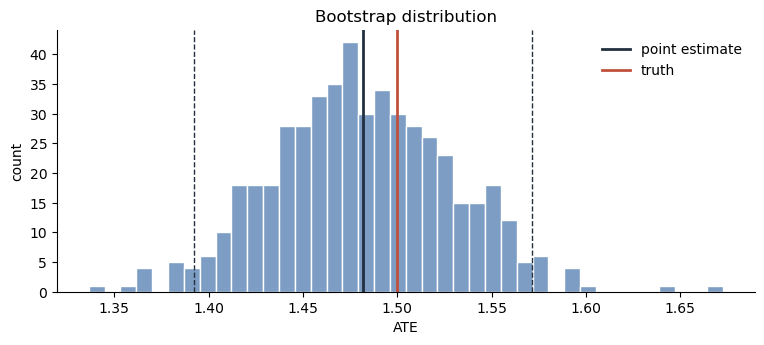

In [22]:
naive = ols(d["Y"], d["A"], d["X"])[1]
oracle = ols(d["Y"], d["A"], d["X"], d["U"])[1]

print(f"true ATE                      {d['truth']:.4f}")
print(f"naive OLS (adjusts X only)    {naive:.4f}   <- confounded")
print(f"oracle OLS (adjusts X and U)  {oracle:.4f}   <- infeasible benchmark")
print(f"proximal 2SLS                 {res.ate:.4f}")

res.plot_bootstrap(truth=d["truth"])
plt.show()

## Failure mode: weak proxies

Weak proxies can break proximal inference's reliability in practice.

The mechanism is similar to how 
weak instruments impact instrumental variables (IV): the variance explodes and the estimate loses informativeness.

strong proxies:  ATE  1.482  se 0.049   relevance Wald =    6767.98
weak proxies:    ATE  2.270  se 0.488   relevance Wald =       6.43


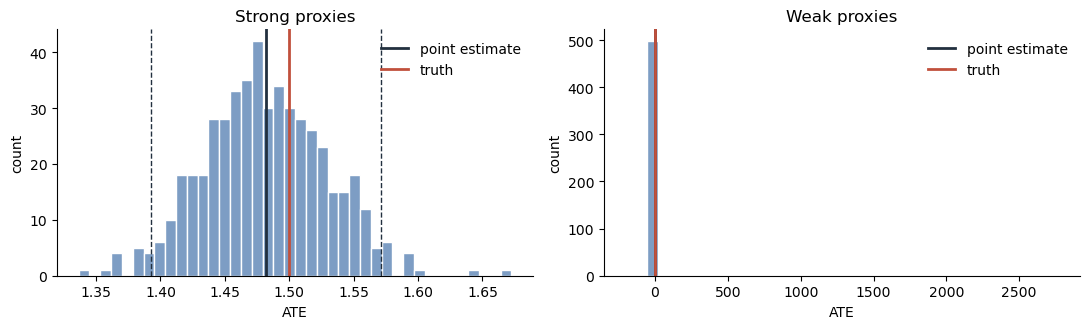

In [23]:
dw = gen_data(n=5000, theta=1.5, alpha_u=0.08, gamma_u=0.08, seed=1)
rw = ProximalTSLS().fit(dw["Y"], dw["A"], dw["W"], dw["Z"], dw["X"], n_boot=500)

print(f"strong proxies:  ATE {res.ate:6.3f}  se {res.se:.3f}   "
      f"relevance Wald = {res.relevance_stat:10.2f}")
print(f"weak proxies:    ATE {rw.ate:6.3f}  se {rw.se:.3f}   "
      f"relevance Wald = {rw.relevance_stat:10.2f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
res.plot_bootstrap(ax=axes[0], truth=1.5)
axes[0].set_title("Strong proxies")
rw.plot_bootstrap(ax=axes[1], truth=1.5)
axes[1].set_title("Weak proxies")
plt.tight_layout()
plt.show()

## Calibration under the simulated DGP

Does the sandwich variance deliver nominal coverage *here*? 300 replications at $n = 2000$ with
strong proxies.

Read the number as a check that the implementation is calibrated in this setting, not as a
general property of the estimator. Coverage degrades once proxies are weak or $n$ is small: a
sweep over randomised sample sizes and proxy strengths puts it nearer 0.92, which is the regime
the weak-proxy section above is about.

mean estimate    1.4972
bias             -0.0028
sd               0.0748
95% coverage     0.953


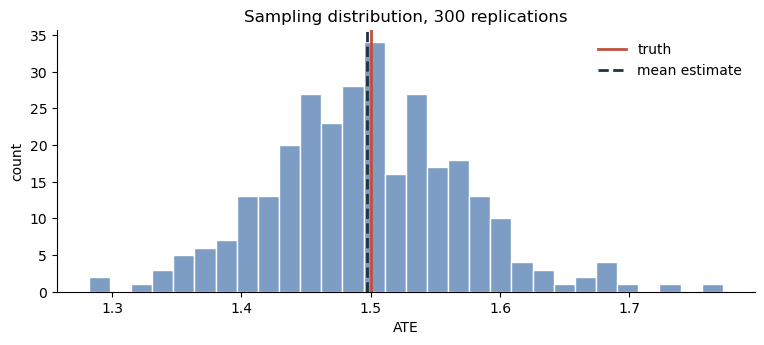

In [24]:
ests, cover = [], 0
for s in range(300):
    dd = gen_data(n=2000, theta=1.5, seed=100 + s)
    rr = ProximalTSLS().fit(dd["Y"], dd["A"], dd["W"], dd["Z"], dd["X"])
    ests.append(rr.ate)
    cover += rr.ci[0] <= 1.5 <= rr.ci[1]

ests = np.array(ests)
print(f"mean estimate    {ests.mean():.4f}")
print(f"bias             {ests.mean() - 1.5:+.4f}")
print(f"sd               {ests.std():.4f}")
print(f"95% coverage     {cover / 300:.3f}")

fig, ax = plt.subplots()
ax.hist(ests, bins=30, color="#7d9dc4", edgecolor="white")
ax.axvline(1.5, color="#c1503c", lw=2, label="truth")
ax.axvline(ests.mean(), color="#22303f", lw=2, ls="--", label="mean estimate")
ax.set(xlabel="ATE", ylabel="count", title="Sampling distribution, 300 replications")
ax.legend(frameon=False)
plt.show()

## Using it on your own data

```python
res = ProximalTSLS().fit(Y, A, W, Z, X)      # W, Z may be multi-column
print(res.summary())
```

Requirements and options:

- $\dim(Z) \ge \dim(W)$, otherwise the fit raises. Supplying a spare $Z$ activates the Hansen
  $J$ test.
- The fit also raises if the design is rank deficient rather than merely ill-conditioned, which
  is what collinear covariates or a duplicated proxy produce. Weak but identified problems still
  run; the relevance statistic is what flags those.
- `interact=True` adds $A \times W$ to the bridge for effect modification by the proxy.
- `n_boot=500` adds a percentile bootstrap interval alongside the analytic one; large
  disagreement between the two is itself a warning sign.

## Where to go next

The natural extension is the **doubly robust proximal estimator** ([Cui, Pu, Shi, Miao &
Tchetgen Tchetgen](https://arxiv.org/abs/2011.08411)), which adds a treatment bridge $q$ acting
as a proximal inverse-probability weight. The resulting influence-function estimator is Neyman
orthogonal, so nuisances can be fit with flexible machine learning while the ATE keeps
$\sqrt{n}$ inference, and it is consistent if *either* bridge is correctly specified. That is
usually the right target once you stop believing the linearity assumption.

## References

**Foundations**

- Miao, W., Geng, Z., & Tchetgen Tchetgen, E. J. (2018). Identifying causal effects with proxy variables of an unmeasured confounder. *Biometrika*, 105(4), 987-993. [arXiv:1609.08816](https://arxiv.org/abs/1609.08816)
  <br>*The original nonparametric identification result via the confounding bridge.*
- Tchetgen Tchetgen, E. J., Ying, A., Cui, Y., Shi, X., & Miao, W. (2024). An Introduction to Proximal Causal Inference. *Statistical Science*, 39(3), 375-390. [journal](https://projecteuclid.org/journals/statistical-science/volume-39/issue-3/An-Introduction-to-Proximal-Causal-Inference/10.1214/23-STS911.short) | [arXiv:2009.10982](https://arxiv.org/abs/2009.10982)
  <br>*The main reference for this notebook, including the P2SLS procedure.*

**Estimation**

- Cui, Y., Pu, H., Shi, X., Miao, W., & Tchetgen Tchetgen, E. J. Semiparametric Proximal Causal Inference. *Journal of the American Statistical Association*, 119, 1348-1359. [arXiv:2011.08411](https://arxiv.org/abs/2011.08411)
  <br>*Doubly robust estimator using both bridges; the "where to go next" target above.*

**Relaxing linearity**

- Mastouri, A., Zhu, Y., Gultchin, L., Korba, A., Silva, R., Kusner, M., Gretton, A., & Muandet, K. (2021). Proximal Causal Learning with Kernels: Two-Stage Estimation and Moment Restriction. *ICML*, PMLR 139. [proceedings](https://proceedings.mlr.press/v139/mastouri21a.html)
  <br>*Kernel bridge estimation, i.e. the "other estimators" of Note 1.*

**Extensions**

- Ying, A., Cui, Y., & Tchetgen Tchetgen, E. J. Proximal Causal Inference for Complex Longitudinal Studies. [arXiv:2109.07030](https://arxiv.org/abs/2109.07030)
  <br>*Time-varying treatments and proxies.*

**Background and identification conditions**

- Shi, X., Miao, W., & Tchetgen Tchetgen, E. J. (2020). A Selective Review of Negative Control Methods in Epidemiology. *Current Epidemiology Reports*, 7(4), 190-202. [arXiv:2009.05641](https://arxiv.org/abs/2009.05641)
  <br>*Where the proxies come from in applied work; $Z$ and $W$ are negative control exposure and outcome.*
- Newey, W. K., & Powell, J. L. (2003). Instrumental Variable Estimation of Nonparametric Models. *Econometrica*, 71(5), 1565-1578.
  <br>*Sufficient conditions for completeness, including the exponential-family and linear-Gaussian cases referenced in the proxy properties above.*
- Canay, I. A., Santos, A., & Shaikh, A. M. (2013). On the Testability of Identification in Some Nonparametric Models with Endogeneity. *Econometrica*, 81(6), 2535-2559.
  <br>*Completeness is untestable: any test of it has power no greater than size.*